In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import snowballstemmer
from nltk.tokenize import word_tokenize
import re
import string
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader,TensorDataset,random_split,Dataset


In [7]:
dataframe=pd.read_csv('Nepali_Dataset_New.csv')
dataframe.head()

,News,Category
0,"\n﻿काठमाण्डौ, ६ असार । नेपाल ललितकला प्रज्ञा प...",politics
1,नेपालको आशा जीवितैकप्तान पारस खड्काले ब्याट र ...,sport
2,"\n﻿राजविराज, २६ फागुन । नेकपा एमालेलाई औद्योगि...",politics
3,"सामाजिक कार्यका लागि सुन्दरी""\nसौन्दर्य प्रतिय...",entertainment
4,"खराब प्रदर्शनपछि प्रशिक्षण पिच""महिला राष्ट्रिय...",sport


In [8]:
dataframe.shape

(4540, 2)

In [9]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4540 entries, 0 to 4539
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   News      4540 non-null   object
 1   Category  4540 non-null   object
dtypes: object(2)
memory usage: 71.1+ KB


In [10]:
dataframe.duplicated().sum()


4

In [11]:
df=dataframe.copy()

In [12]:
df['News'][0]

'\n\ufeffकाठमाण्डौ, ६ असार । नेपाल ललितकला प्रज्ञा प्रतिष्ठानले लोककला विधामा प्रदान गरेको पुरस्कार विवादमा परेको छ ।\nप्रतिष्ठानले सोमवार काठमाडौंमा आयोजना गरेको सातौं राष्ट्रिय चित्रकला प्रदर्शनीमा मिथिला चित्रकार कमला सुतिहारलाई लोककला विधाअन्तर्गत राष्ट्रिय ललितकला पुरस्कार प्रदान गरेको थियो । बबरमहलको नेपाल कला परिषद्स्थित चित्रकला प्रदर्शनीस्थल मङ्गलवार पत्रकार सम्मेलन गर्दै करिव एक दर्जन लोककलाकारहरुले कमला सुतिहारलाई नातावाद, कृपावाद र राजनीतिक प्रभावको आधारमा उक्त पुरस्कार दिइएको आरोप लगाएका छन् ।\xa0असन्तुष्ट कलाकारहरुले सिकारु कलाकार सुतिहारको क्षमता र कलाकृतिको आधारमा नभइ अमुक नेता तथा सांसद्की पत्नी भएकै आधारमा उनलाई राष्ट्रिय स्तरको पुरस्कार दिइएको दाबी समेत गरेका छन् ।\n‘अमुक पार्टीको कोटामा प्रतिष्ठानको प्राज्ञ बनेका लोककला विभागका प्रमुख सुबोधचन्द्र दास (एससी सुमन)ले अर्को कार्यकालकालागि आफू फेरी प्राज्ञ बन्ने लोभले सभासद् पत्नीलाई पुरस्कार प्रदान गरेर मिथिला चित्रकलासहित नेपालको लोककला जगत र सम्पूर्ण कला क्षेत्रको शिर नै लाज र अपमानबोधले निहुरिएको विज्ञप्तिमा जनाइएको 

In [13]:
df['Category'].unique()

array(['politics', 'sport', 'entertainment', 'tech', 'business'],
      dtype=object)

In [14]:
nepali_punctuation = "।,?!;:\"'()[]{}-…"
custom_punctuation=string.punctuation+nepali_punctuation

In [15]:
import nltk
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
def preprocessed_text(text):
    pattern = r'[^\u0900-\u095F\u0970-\u097F\s]'
    text=re.sub(pattern,'',text)
    text=text.translate(str.maketrans('','',custom_punctuation))
    tokens=word_tokenize(text)
    stop_word=set(stopwords.words('nepali'))
    tokens=[word for word in tokens if word not in stop_word]
    stemmer=snowballstemmer.stemmer('nepali')
    tokens=[stemmer.stemWord(word) for word in tokens]
    clean_text=' '.join(tokens)
    return clean_text


df['clean_news']=df['News'].apply(preprocessed_text)

In [17]:
df['Category'].value_counts()

,count
Category,
sport,1000
entertainment,1000
tech,1000
business,1000
politics,540


In [ ]:
df['text_length']=df['clean_news'].apply(len)
plt.figure(figsize=(12,8))
sns.histplot(df['text_length'],kde=True)
plt.title("Distribution of text_length")
plt.show()

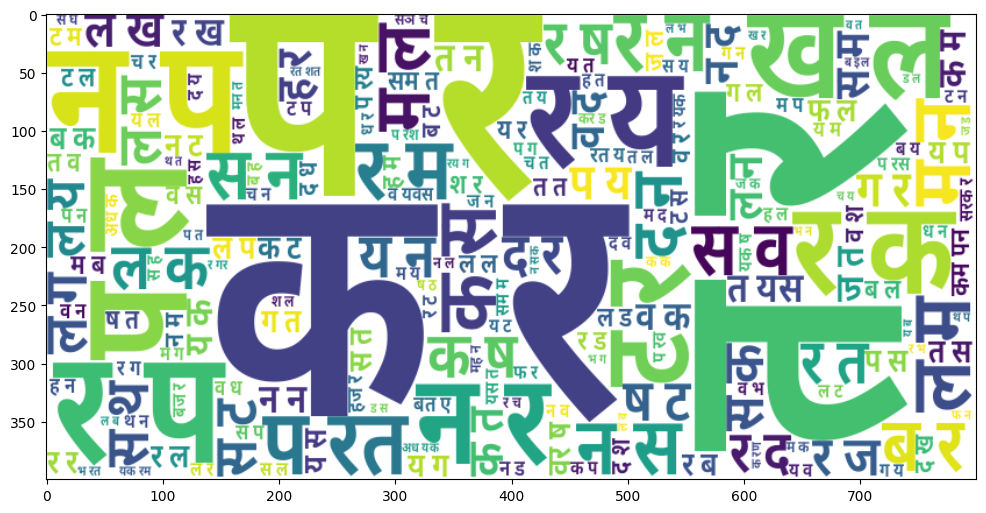

In [14]:
from wordcloud import WordCloud
all_text=" ".join(df['clean_news'])
wordclouds=WordCloud(width=800,height=400,background_color='white',font_path=r"/content/NotoSansDevanagari_Condensed-SemiBold.ttf").generate(all_text)
plt.figure(figsize=(12,8))
plt.imshow(wordclouds,interpolation='bilinear')


In [15]:
from collections import Counter
all_text=' '.join(df['clean_news'])
tokens=word_tokenize(all_text)
word_freq=Counter(tokens)
word_freq_df=pd.DataFrame(word_freq.items(),columns=['words','frequency']).sort_values(by='frequency',ascending=False)
print(word_freq_df)

             words  frequency
2            नेपाल       8424
274            गर्       5079
53               भ       4914
602         कम्पनी       4575
137           वर्ष       4552
...            ...        ...
70233    कम्बिनेसन          1
70234       भ्युइङ          1
70235  निस्केजस्तो          1
70236  फिटविटलगायत          1
70237      डीएनएलए          1

[70255 rows x 2 columns]


In [16]:
# Function to count words in text
def count_words(text):
    words = text.split()
    return Counter(words)

# Group by category and calculate word counts
word_counts = df.groupby('Category')['clean_news'].apply(lambda x: ' '.join(x)).apply(count_words)


In [17]:
word_count_df=pd.DataFrame(word_counts.tolist(),index=word_counts.index).fillna(0).astype(int)

In [18]:
word_count_df

,लुम्बिनी,सिलिन्डर,केजीसम्म,कम,ग्यासवाणिज्य,विभाग,गुणस्तर,नापतौल,छुट्टाछुट्टै,अनुगमन,...,टचअप,कम्बिनेसन,भ्युइङ,निस्केजस्तो,फिटविटलगायत,डीएनएलए,इन्फ्रारेड,ग्लोनस,एक्सिटि्रम,ब्युझाइरह
Category,,,,,,,,,,,,,,,,,,,,,
business,70,156,2,581,1,761,125,11,27,206,...,0,0,0,0,0,0,0,0,0,0
entertainment,29,0,0,107,0,22,11,0,11,3,...,0,0,0,0,0,0,0,0,0,0
politics,2,0,0,5,0,35,1,0,4,35,...,0,0,0,0,0,0,0,0,0,0
sport,7,0,0,129,0,7,8,0,3,3,...,0,0,0,0,0,0,0,0,0,0
tech,4,2,1,306,0,80,172,0,29,17,...,1,1,1,1,1,1,1,1,1,1


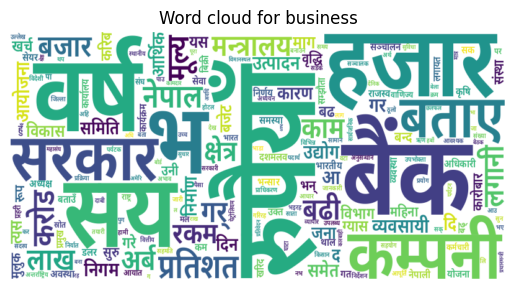

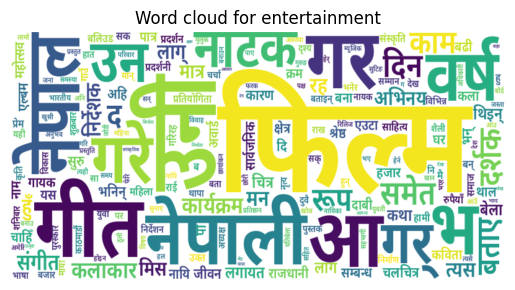

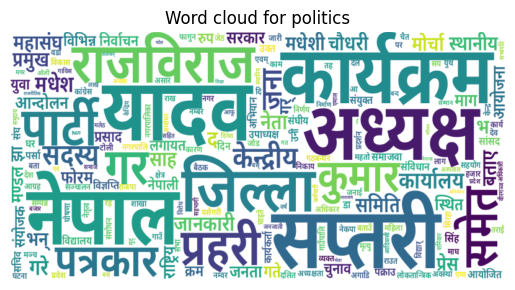

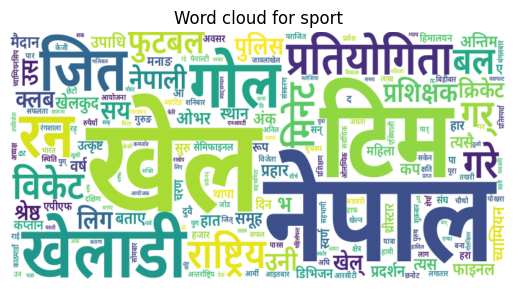

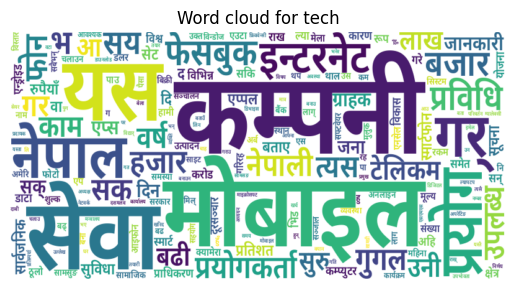

In [19]:
def generate_wordcloud(word_count_df):
    for category in word_count_df.index:
        word_freq=word_count_df.loc[category]
        wordcloud=WordCloud(width=800,height=400,background_color='White',font_path=r"/content/NotoSansDevanagari_Condensed-SemiBold.ttf").generate_from_frequencies(word_freq)

        plt.imshow(wordcloud,interpolation='bilinear')
        plt.title(f"Word cloud for {category}")
        plt.axis('off')
        plt.show()

generate_wordcloud(word_count_df)


In [20]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['Category']=encoder.fit_transform(df['Category'])
cateory=encoder.classes_

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
X=df['clean_news']
y=df['Category']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


vectorizer=TfidfVectorizer()
X_train=vectorizer.fit_transform(X_train)
X_test=vectorizer.transform(X_test)

In [22]:
#  Applying Logistic Regression
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression()
model_lg=lg.fit(X_train, y_train)


In [23]:
from sklearn.metrics import accuracy_score,classification_report

In [24]:
def model_evaluate(model,X_test,y_test):
    y_pred=model.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    print(classification_report(y_test,y_pred))

In [25]:

model_evaluate(lg,X_test,y_test)

0.9449339207048458
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       212
           1       0.93      0.96      0.94       194
           2       0.98      0.95      0.97       117
           3       0.97      0.95      0.96       186
           4       0.94      0.93      0.94       199

    accuracy                           0.94       908
   macro avg       0.95      0.95      0.95       908
weighted avg       0.95      0.94      0.95       908



In [26]:
def news_classification(news):
    text=preprocessed_text(news)
    input_data=[news]
    vector_form1=vectorizer.transform(input_data)
    prediction = lg.predict(vector_form1)
    return prediction

In [27]:
news_classification('कर्णाली प्रदेश खेलकुद परिषद्ले निर्माण सम्पन्न भएको कालुङचोक क्रिकेट मैदान कर्णाली प्रदेश क्रिकेट संघलाई हस्तान्तरण गरेको छ । संघको दोस्रो वार्षिकोत्सव कार्यक्रममा परिषद्का सदस्यसचिव विश्वामित्र सञ्ज्यालले प्रदेश अध्यक्ष एवं क्यान कोषाध्यक्ष पदमबहादुर खड्कालाई मैदान हस्तान्तरणको पत्र दिए ।')

array([2])

In [28]:
# preview of our encoded labels
le_name_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
le_name_mapping

{'business': 0, 'entertainment': 1, 'politics': 2, 'sport': 3, 'tech': 4}

In [29]:
!pip install gensim

In [30]:
from gensim.models import Word2Vec
tokenized_text=df['clean_news'].str.split()
w2v_model=Word2Vec(sentences=tokenized_text,vector_size=100,window=5,min_count=1)

In [31]:
# def text_to_embedding(tokens, w2v_model, max_len=100, embedding_dim=100):
#     embeddings = []
#     for token in tokens:
#         if token in w2v_model.wv:
#             embeddings.append(w2v_model.wv[token])
#         else:
#             embeddings.append(np.zeros(embedding_dim))

#     # Padding
#     if len(embeddings) > max_len:
#         embeddings = embeddings[:max_len]
#     else:
#         padding = [np.zeros(embedding_dim) for _ in range(max_len - len(embeddings))]
#         embeddings.extend(padding)

#     return np.array(embeddings)
# df1=df.copy()
# df1['tokens']=df1['clean_news'].apply(lambda x:word_tokenize(x))
# df1['sequence_length']=df1['tokens'].apply(len)
# max_len=100
# embedding_dim=100
# # Apply the embedding function to each row
#   # Define maximum sequence length for padding
# df1['embedding_sequence'] = df1['tokens'].apply(lambda x: text_to_embedding(x, w2v_model, max_len=max_len, embedding_dim=embedding_dim))




In [32]:

X = np.stack(df1['embedding_sequence'].values)
y = df1['Category'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to torch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# Label encoding
label_mapping = {label: idx for idx, label in enumerate(df1['Category'].unique())}
df1['label'] = df1['Category'].map(label_mapping)
X_test.shape

torch.Size([908, 100, 100])

In [33]:
X_train[0]

tensor([[-0.4500,  0.6605,  0.3953,  ..., -0.8285, -0.8817,  0.7098],
        [-1.3672,  0.5642,  0.7257,  ..., -0.8991, -1.3915,  0.6405],
        [ 1.1118, -0.3088, -0.0606,  ..., -1.1998,  0.6663,  0.2338],
        ...,
        [-1.2557,  0.5288,  0.4788,  ...,  0.2258, -0.2132, -0.1258],
        [-0.4620,  0.1710, -0.3943,  ..., -1.9978, -0.3662,  0.0288],
        [-0.2494,  0.5245,  0.2942,  ..., -0.2512, -0.2551,  0.0300]])

In [34]:
# class NewsDataset(Dataset):
#     def __init__(self, df, max_len, embedding_dim=100):
#         self.embedding_sequences = df['embedding_sequence'].values  # Make sure this is a list/array of embeddings
#         self.labels = df['label'].values  # Integer labels
#         self.max_len = max_len
#         self.embedding_dim = embedding_dim

#     def __len__(self):
#         return len(self.labels)

#     def __getitem__(self, idx):
#         # Fetch embedding sequence and label at index 'idx'
#         embedding_sequence = self.embedding_sequences[idx]
#         label = self.labels[idx]

#         # Ensure that embedding_sequence is a numpy array
#         if not isinstance(embedding_sequence, np.ndarray):
#             embedding_sequence = np.array(embedding_sequence)

#         # Pad or truncate the sequence to the fixed length
#         if len(embedding_sequence) > self.max_len:
#             embedding_sequence = embedding_sequence[:self.max_len]
#         else:
#             padding = np.zeros((self.max_len - len(embedding_sequence), self.embedding_dim))
#             embedding_sequence = np.vstack([embedding_sequence, padding])

#         # Convert to PyTorch tensors
#         embedding_tensor = torch.tensor(embedding_sequence, dtype=torch.float32)
#         label_tensor = torch.tensor(label, dtype=torch.long)

#         return embedding_tensor, label_tensor

In [35]:


# max_len = 100  # Maximum length of sequence
# embedding_dim = 100  # Dimension of embedding (depends on your model)

# # Step 4: Create an instance of NewsDataset
# dataset = NewsDataset(df1, max_len=max_len, embedding_dim=embedding_dim)
# dataset_size = len(dataset)
# train_size = int(0.7 * dataset_size)  # 70% for training
# val_size = int(0.15 * dataset_size)   # 15% for validation
# test_size = dataset_size - train_size - val_size  # Remaining for testing

# # Randomly split the dataset
# train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))

# # Step 6: Create DataLoaders for batching and shuffling
# batch_size = 32

# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)



In [36]:
max_len

100

In [37]:
class NewsClassifier(nn.Module):
  def __init__(self,vocab_size,embeding_dim,hidden_size,num_layers,output_dim,dropout=0.2):
    super(NewsClassifier,self).__init__()
    self.hidden_size=hidden_size
    self.num_layers=num_layers
    # self.embedding=nn.Embedding(vocab_size,embedding_dim)
    self.lstm=nn.LSTM(embedding_dim,hidden_size,num_layers,batch_first=True,dropout=dropout)
    # self.fc=nn.Linear(hidden_size*num_layers,output_dim)
    self.fc=nn.Linear(hidden_size,output_dim)
    self.dropout=nn.Dropout(dropout)

  def forward(self,x):
    # x=self.embedding(x)
    h0=torch.zeros(self.num_layers,x.size(0),self.hidden_size).to(device)
    c0=torch.zeros(self.num_layers,x.size(0),self.hidden_size).to(device)
    out,_=self.lstm(x,(h0,c0))
    out=self.fc(self.dropout(out[:,-1,:]))
    return out
vocab_size=len(w2v_model.wv)
embedding_dim=100
num_layers=3
hidden_size=128
output_dim=len(df['Category'].unique())
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model=NewsClassifier(vocab_size,embedding_dim,hidden_size,num_layers,output_dim).to(device)


# print(device)

In [38]:
def train_model(model, X_train, y_train, X_test, y_test, loss_fn, optimizer, epochs):
    train_loss_values = []
    val_loss_values = []
    train_acc_values = []
    val_acc_values = []

    for epoch in range(epochs):
        # Set the model to training mode
        model.train()

        # Zero out gradients
        optimizer.zero_grad()

        # Forward pass
        X_train = X_train.to(device)
        y_train = y_train.to(device)
        outputs = model(X_train)
        loss = loss_fn(outputs, y_train)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Compute training accuracy
        train_acc = (outputs.argmax(1) == y_train).float().mean()
        train_loss_values.append(loss.item())
        train_acc_values.append(train_acc.item())

        print(f'Epoch [{epoch+1}/{epochs}] - Training Loss: {loss.item():.4f}, Training Accuracy: {train_acc.item() * 100:.2f}%')

        # Set the model to evaluation mode for validation
        model.eval()
        with torch.no_grad():
            X_test = X_test.to(device)
            y_test = y_test.to(device)
            val_outputs = model(X_test)
            val_loss = loss_fn(val_outputs, y_test)

            # Compute validation accuracy
            val_acc = (val_outputs.argmax(1) == y_test).float().mean()
            val_loss_values.append(val_loss.item())
            val_acc_values.append(val_acc.item())

            print(f'Validation Loss: {val_loss.item():.4f}, Validation Accuracy: {val_acc.item() * 100:.2f}%')

    return train_loss_values, val_loss_values, train_acc_values, val_acc_values




In [39]:
import torch.nn as nn
from torch.optim.lr_scheduler import StepLR
learning_rate = 0.001
batch_size = 32
epochs = 50
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
train_loss_values, val_loss_values, train_acc_values, val_acc_values = train_model(
    model, X_train, y_train, X_test, y_test, loss_fn, optimizer, epochs=epochs
)

Epoch [1/50] - Training Loss: 1.6065, Training Accuracy: 21.70%
Validation Loss: 1.5955, Validation Accuracy: 23.35%
Epoch [2/50] - Training Loss: 1.5962, Training Accuracy: 21.70%
Validation Loss: 1.5853, Validation Accuracy: 23.35%
Epoch [3/50] - Training Loss: 1.5850, Training Accuracy: 21.94%
Validation Loss: 1.5731, Validation Accuracy: 30.51%
Epoch [4/50] - Training Loss: 1.5724, Training Accuracy: 29.05%
Validation Loss: 1.5570, Validation Accuracy: 40.75%
Epoch [5/50] - Training Loss: 1.5550, Training Accuracy: 40.14%
Validation Loss: 1.5346, Validation Accuracy: 50.77%
Epoch [6/50] - Training Loss: 1.5323, Training Accuracy: 49.64%
Validation Loss: 1.5032, Validation Accuracy: 60.13%
Epoch [7/50] - Training Loss: 1.5000, Training Accuracy: 56.99%
Validation Loss: 1.4587, Validation Accuracy: 63.55%
Epoch [8/50] - Training Loss: 1.4537, Training Accuracy: 60.16%
Validation Loss: 1.3960, Validation Accuracy: 64.98%
Epoch [9/50] - Training Loss: 1.3886, Training Accuracy: 62.50%


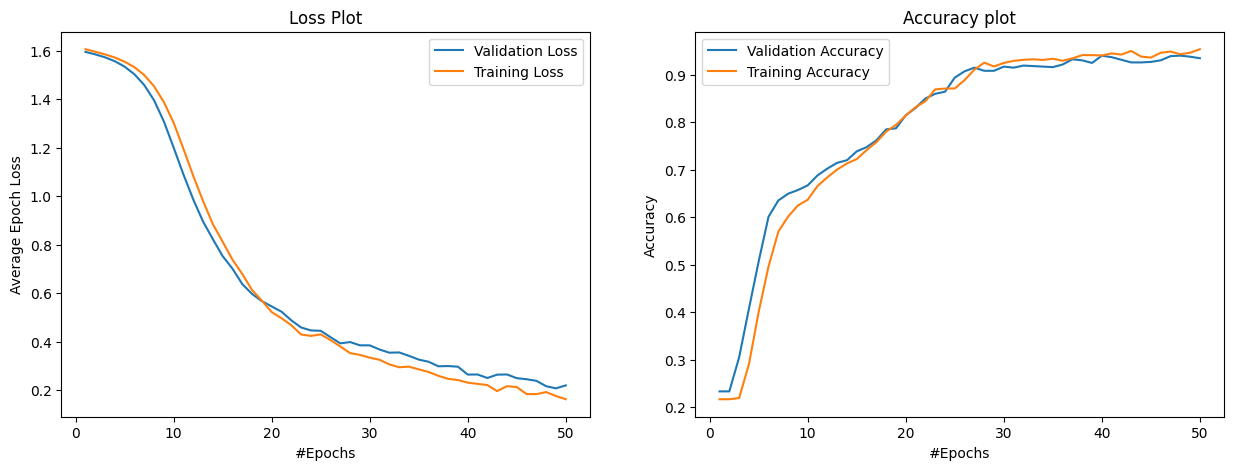

In [40]:
# cell 40
val_interval = 1
plt.figure(figsize=(15, 5))

# Subplot for training and validation loss
plt.subplot(1, 2, 1)
plt.title("Loss Plot")
train_num_epoch = [i + 1 for i in range(len(train_loss_values))]
val_num_epoch = [val_interval * (i + 1) for i in range(len(val_loss_values))]
plt.plot(val_num_epoch, val_loss_values)
plt.plot(train_num_epoch, train_loss_values)
plt.legend(["Validation Loss", "Training Loss"])
plt.xlabel("#Epochs")
plt.ylabel("Average Epoch Loss")

# Subplot for validation accuracy
plt.subplot(1, 2, 2)
train_num_epoch = [i + 1 for i in range(len(train_acc_values))]
val_num_epoch = [val_interval * (i + 1) for i in range(len(val_acc_values))]
plt.plot(val_num_epoch, val_acc_values)
plt.plot(train_num_epoch, train_acc_values)
plt.legend(["Validation Accuracy", "Training Accuracy"])
plt.title("Accuracy plot")
plt.xlabel("#Epochs")
plt.ylabel("Accuracy")
plt.show()

In [41]:
def predict(news,w2v_model, max_len=100, embedding_dim=100):
  news = preprocessed_text(news)
  # The text_to_embedding function only takes 3 arguments: news, w2v_model, and max_len
  news = text_to_embedding(news, w2v_model, max_len)
  news = torch.tensor(news, dtype=torch.float32)
  news = news.unsqueeze(0)
  news=news.to(device)
  with torch.no_grad():
    output = model(news)
  _, predicted = torch.max(output, 1)
  print(f'Predicted Class: {predicted.item()}')

In [ ]:



predict('एजेन्सी । एप्पल कम्पनीले वहुप्रतिक्षित आईफोन १६ को सिरिज सार्वजनिक गरेको छ । सेप्टेम्बर ९ अर्थात् सोमबार अमेरिकाको क्यालिफोर्नियास्थित एप्पल पार्कमा आयोजित इभेन्टमा आईफोन १६, आईफोन १६ प्लस, आईफोन १६ प्रो र आईफोन १६ प्रो म्याक्स सार्वजनिक गरियो ।', w2v_model, 100, 100)


Predicted Class: 1


In [43]:
encoder.classes_

array(['business', 'entertainment', 'politics', 'sport', 'tech'],
      dtype=object)

In [44]:
# prompt: generate the GRU model

class NewsClassifierGRU(nn.Module):
  def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, output_dim, dropout=0.2):
    super(NewsClassifierGRU, self).__init__()
    self.hidden_size = hidden_size
    self.num_layers = num_layers
    # self.embedding = nn.Embedding(vocab_size, embedding_dim)
    self.gru = nn.GRU(embedding_dim, hidden_size, num_layers, batch_first=True, dropout=dropout)
    # self.fc = nn.Linear(hidden_size * num_layers, output_dim)
    self.fc = nn.Linear(hidden_size, output_dim)
    self.dropout = nn.Dropout(dropout)

  def forward(self, x):
    # x = self.embedding(x)
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
    out, _ = self.gru(x, h0)
    out = self.fc(self.dropout(out[:, -1, :]))
    return out
embedding_dim=100
hidden_size=128
num_layers=2
output_dim=len(df['Category'].unique())
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gru_model=NewsClassifierGRU(vocab_size,embedding_dim,hidden_size,num_layers,output_dim).to(device)


In [45]:
import torch.nn as nn
from torch.optim.lr_scheduler import StepLR
learning_rate = 0.01
batch_size = 32
epochs = 50
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

train_loss_values, val_loss_values, train_acc_values, val_acc_values = train_model(
    gru_model, X_train, y_train, X_test, y_test, loss_fn, optimizer, epochs=epochs
)

Epoch [1/50] - Training Loss: 1.6090, Training Accuracy: 27.18%
Validation Loss: 1.6136, Validation Accuracy: 30.95%
Epoch [2/50] - Training Loss: 1.6093, Training Accuracy: 25.83%
Validation Loss: 1.6136, Validation Accuracy: 30.95%
Epoch [3/50] - Training Loss: 1.6088, Training Accuracy: 26.98%
Validation Loss: 1.6136, Validation Accuracy: 30.95%
Epoch [4/50] - Training Loss: 1.6089, Training Accuracy: 26.90%
Validation Loss: 1.6136, Validation Accuracy: 30.95%
Epoch [5/50] - Training Loss: 1.6104, Training Accuracy: 25.63%
Validation Loss: 1.6136, Validation Accuracy: 30.95%
Epoch [6/50] - Training Loss: 1.6092, Training Accuracy: 26.49%
Validation Loss: 1.6136, Validation Accuracy: 30.95%
Epoch [7/50] - Training Loss: 1.6086, Training Accuracy: 27.45%
Validation Loss: 1.6136, Validation Accuracy: 30.95%
Epoch [8/50] - Training Loss: 1.6079, Training Accuracy: 27.97%
Validation Loss: 1.6136, Validation Accuracy: 30.95%
Epoch [9/50] - Training Loss: 1.6101, Training Accuracy: 26.02%


In [46]:
w2v_weights=df1['embedding_sequence']

In [47]:
# model = Sequential()

# # Keras Embedding layer with Word2Vec weights initialization
# model.add(Embedding(input_dim=vocab_size,
#                     output_dim=embedding_size,
#                     weights=[w2v_weights],
#                     input_length=MAX_SEQUENCE_LENGTH,
#                     mask_zero=True,
#                     trainable=False))

# model.add(Bidirectional(LSTM(100)))
# model.add(Dense(n_categories, activation='softmax'))

# model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [149]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from gensim.models import Word2Vec
import numpy as np
import pandas as pd

# Assuming df is your DataFrame
X = df['clean_news']
y = df['Category']

# Step 1: Tokenizing the text data
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(X)

# Convert text to sequences
X = tokenizer.texts_to_sequences(X)

# Pad sequences to ensure uniform input length
X = pad_sequences(X, padding='post', maxlen=100)

# Step 2: Encoding labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Step 3: Train a Word2Vec model on the tokenized text
tokenized_sentences =df['clean_news'].apply(lambda x: x.split())
word2vec_model = Word2Vec(sentences=tokenized_sentences, vector_size=128, window=5, min_count=1, workers=4)

# Step 4: Create an embedding matrix
vocab_size = len(tokenizer.word_index) + 1  # Ensure the vocabulary size matches the tokenizer
embedding_dim = 128
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        if word in word2vec_model.wv:
            embedding_matrix[i] = word2vec_model.wv[word]
        else:
            embedding_matrix[i] = np.random.normal(size=(embedding_dim,))

# Step 5: Define the GRU model in PyTorch



# Training settings
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# # Training loop
# epochs = 50
# patience = 3
# best_val_loss = float('inf')
# early_stopping_counter = 0

# for epoch in range(epochs):
#     model.train()
#     total_loss = 0
#     for X_batch, y_batch in train_loader:
#         optimizer.zero_grad()
#         outputs = model(X_batch)
#         loss = criterion(outputs, y_batch)
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()

#     # Validation
#     model.eval()
#     val_loss = 0
#     all_preds = []
#     with torch.no_grad():
#         for X_batch, y_batch in test_loader:
#             outputs = model(X_batch)
#             loss = criterion(outputs, y_batch)
#             val_loss += loss.item()
#             preds = torch.argmax(outputs, dim=1)
#             all_preds.extend(preds.numpy())

#     val_loss /= len(test_loader)

#     # Early stopping
#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         early_stopping_counter = 0
#         torch.save(model.state_dict(), 'best_model.pth')  # Save the best model
#     else:
#         early_stopping_counter += 1

#     if early_stopping_counter >= patience:
#         print(f"Early stopping at epoch {epoch+1}")
#         break

#     print(f'Epoch {epoch+1}, Training Loss: {total_loss/len(train_loader)}, Validation Loss: {val_loss}')

# # Load the best model
# model.load_state_dict(torch.load('best_model.pth'))

# # Step 7: Evaluate the model
# model.eval()
# y_pred = []
# with torch.no_grad():
#     for X_batch, _ in test_loader:
#         outputs = model(X_batch)
#         preds = torch.argmax(outputs, dim=1)
#         y_pred.extend(preds.numpy())

# accuracy = accuracy_score(y_test, y_pred)
# report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)

# print(f"Accuracy: {accuracy}")
# print("Classification Report:")
# print(report)

# Step 8: Define a function to classify new sentences




In [150]:
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, embedding_matrix, output_size, hidden_dim, n_layers, dropout_prob):
        super(GRUModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight = nn.Parameter(torch.tensor(embedding_matrix, dtype=torch.float32))
        self.embedding.weight.requires_grad = False  # Set to False if you don't want to train the embeddings

        self.gru = nn.GRU(embedding_dim, hidden_dim, num_layers=n_layers, bidirectional=True, batch_first=True)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_dim * 2, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        gru_output, hidden = self.gru(embedded)
        gru_output = self.dropout(gru_output[:, -1, :])  # Only take the output of the last time step
        output = self.fc(gru_output)
        return output

# Initialize the model
output_size = len(label_encoder.classes_)
hidden_dim = 128
n_layers = 1
dropout_prob = 0.3

model = GRUModel(vocab_size, embedding_dim, embedding_matrix, output_size, hidden_dim, n_layers, dropout_prob)



In [151]:
# def trainnin(model,train_loader,test_loader,):

#   # Training loop
#   epochs = 50
#   patience = 3
#   best_val_loss = float('inf')
#   early_stopping_counter = 0

#   for epoch in range(epochs):
#       model.train()
#       total_loss = 0
#       for X_batch, y_batch in train_loader:
#           optimizer.zero_grad()
#           outputs = model(X_batch)
#           loss = criterion(outputs, y_batch)
#           loss.backward()
#           optimizer.step()
#           total_loss += loss.item()

#       # Validation
#       model.eval()
#       val_loss = 0
#       all_preds = []
#       with torch.no_grad():
#           for X_batch, y_batch in test_loader:
#               outputs = model(X_batch)
#               loss = criterion(outputs, y_batch)
#               val_loss += loss.item()
#               preds = torch.argmax(outputs, dim=1)
#               all_preds.extend(preds.numpy())

#       val_loss /= len(test_loader)

#       # Early stopping
#       if val_loss < best_val_loss:
#           best_val_loss = val_loss
#           early_stopping_counter = 0
#           torch.save(model.state_dict(), 'best_model.pth')  # Save the best model
#       else:
#           early_stopping_counter += 1

#       if early_stopping_counter >= patience:
#           print(f"Early stopping at epoch {epoch+1}")
#           break

#       print(f'Epoch {epoch+1}, Training Loss: {total_loss/len(train_loader)}, Validation Loss: {val_loss}')


In [152]:
# def train_model(model, X_train, y_train, X_test, y_test, loss_fn, optimizer, epochs):
#     train_loss_values = []
#     val_loss_values = []
#     train_acc_values = []
#     val_acc_values = []

#     for epoch in range(epochs):
#         # Set the model to training mode
#         model.train()

#         # Zero out gradients
#         optimizer.zero_grad()
#         for X_batch, y_batch in train_loader:

#         outputs = model(X_train)
#         loss = loss_fn(outputs, y_train)

#         # Backward pass and optimization
#         loss.backward()
#         optimizer.step()

#         # Compute training accuracy
#         train_acc = (outputs.argmax(1) == y_train).float().mean()
#         train_loss_values.append(loss.item())
#         train_acc_values.append(train_acc.item())

#         print(f'Epoch [{epoch+1}/{epochs}] - Training Loss: {loss.item():.4f}, Training Accuracy: {train_acc.item() * 100:.2f}%')

#         # Set the model to evaluation mode for validation
#         model.eval()
#         with torch.no_grad():
#             X_test = X_test.to(device)
#             y_test = y_test.to(device)
#             val_outputs = model(X_test)
#             val_loss = loss_fn(val_outputs, y_test)

#             # Compute validation accuracy
#             val_acc = (val_outputs.argmax(1) == y_test).float().mean()
#             val_loss_values.append(val_loss.item())
#             val_acc_values.append(val_acc.item())

#             print(f'Validation Loss: {val_loss.item():.4f}, Validation Accuracy: {val_acc.item() * 100:.2f}%')

#     return train_loss_values, val_loss_values, train_acc_values, val_acc_values




In [153]:
import numpy as np
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


In [154]:
def train(model,train_dataloader, val_dataloader, loss_fn, optimizer, epochs, val_interval=1,save_path=None):
    early_stopping = EarlyStopping(patience=3, min_delta=0.001)
    train_loss_values = []
    val_loss_values = []
    train_accuracy_values=[]
    val_accuracy_values = []
    best_val_loss = float('inf')
    # Training loop
    for epoch in range(epochs):
        print("-" * 10)
        print(f"epoch {epoch + 1}/{epochs}")
        model.train()   # set model on training mode
        epoch_loss = 0
        val_epoch_loss = 0
        step = 0
        epoch_correct_count = 0
        correct_count = 0
        for X_batch,y_batch in train_dataloader:
            step += 1
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)   # Batch loss
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            epoch_correct_count += (outputs.argmax(1) == y_batch).type(torch.float).sum().item()

        epoch_loss /= step
        train_loss_values.append(epoch_loss)
        train_accuracy = epoch_correct_count / len(train_dataloader.dataset)
        train_accuracy_values.append(train_accuracy)
        print(f"Epoch {epoch + 1} average training loss: {epoch_loss:.4f}")
        print(f"Epoch {epoch + 1} training accuracy: {100 * train_accuracy:.1f}%")

        # Validation loop
        if (epoch + 1) % val_interval == 0:
            model.eval()    # Setting model in eval mode
            with torch.no_grad():
                val_step = 0
                for valx,valy in val_dataloader:
                    val_step += 1
                    outputs = model(valx)
                    loss = loss_fn(outputs, valy)   # Batch loss
                    val_epoch_loss += loss.item()
                    correct_count += (outputs.argmax(1) == valy).type(torch.float).sum().item()
                    # print(correct_count)
            val_epoch_loss /= val_step
            accuracy = correct_count / len(val_dataloader.dataset)
            val_loss_values.append(val_epoch_loss)
            val_accuracy_values.append(accuracy)
            print(f"Epoch {epoch + 1} average validation loss: {val_epoch_loss:.4f}")
            print(f"Validation Accuracy: {(100 * accuracy):>0.1f}% \n")

            early_stopping(val_epoch_loss)
            if early_stopping.early_stop:
              print("Early stopping triggered.")
              break
            if val_epoch_loss < best_val_loss:
                best_val_loss = val_epoch_loss
                torch.save(model.state_dict(), save_path)
                print(f"Saved best model with validation loss: {best_val_loss:.4f}")

    return train_loss_values, val_loss_values, train_accuracy_values,val_accuracy_values


In [ ]:
learning_rate = 1e-3
batch_size = 64
epochs = 50

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
train_loss_values, val_loss_values,train_accuracy_values, val_accuracy_values = train(model,train_loader, test_loader, loss_fn, optimizer, epochs, val_interval=1,save_path='model/gru_best_model.pth')

----------
epoch 1/50
Epoch 1 average training loss: 1.1702
Epoch 1 training accuracy: 55.0%
Epoch 1 average validation loss: 0.7470
Validation Accuracy: 73.3% 

Saved best model with validation loss: 0.7470
----------
epoch 2/50
Epoch 2 average training loss: 0.5107
Epoch 2 training accuracy: 83.0%
Epoch 2 average validation loss: 0.3970
Validation Accuracy: 88.5% 

Saved best model with validation loss: 0.3970
----------
epoch 3/50
Epoch 3 average training loss: 0.3186
Epoch 3 training accuracy: 90.3%
Epoch 3 average validation loss: 0.2754
Validation Accuracy: 92.1% 

Saved best model with validation loss: 0.2754
----------
epoch 4/50
Epoch 4 average training loss: 0.2566
Epoch 4 training accuracy: 91.9%
Epoch 4 average validation loss: 0.2306
Validation Accuracy: 92.6% 

Saved best model with validation loss: 0.2306
----------
epoch 5/50
Epoch 5 average training loss: 0.2114
Epoch 5 training accuracy: 93.3%
Epoch 5 average validation loss: 0.2082
Validation Accuracy: 93.5% 

Saved 

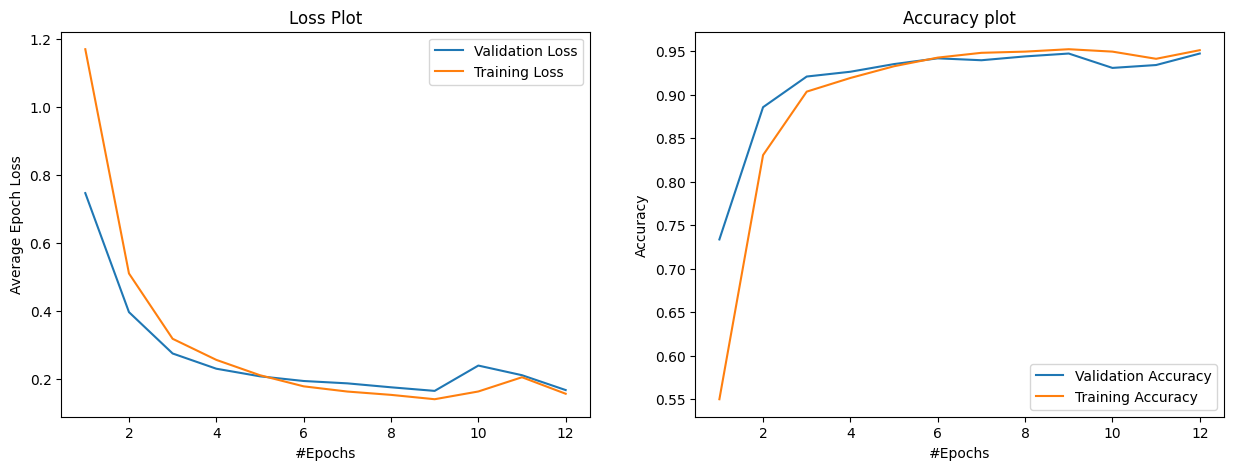

In [156]:
# cell 40
val_interval = 1
plt.figure(figsize=(15, 5))

# Subplot for training and validation loss
plt.subplot(1, 2, 1)
plt.title("Loss Plot")
train_num_epoch = [i + 1 for i in range(len(train_loss_values))]
val_num_epoch = [val_interval * (i + 1) for i in range(len(val_loss_values))]
plt.plot(val_num_epoch, val_loss_values)
plt.plot(train_num_epoch, train_loss_values)
plt.legend(["Validation Loss", "Training Loss"])
plt.xlabel("#Epochs")
plt.ylabel("Average Epoch Loss")

# Subplot for validation accuracy
plt.subplot(1, 2, 2)
train_num_epoch = [i + 1 for i in range(len(train_accuracy_values))]
val_num_epoch = [val_interval * (i + 1) for i in range(len(val_accuracy_values))]
plt.plot(val_num_epoch, val_accuracy_values)
plt.plot(train_num_epoch, train_accuracy_values)
plt.legend(["Validation Accuracy", "Training Accuracy"])
plt.title("Accuracy plot")
plt.xlabel("#Epochs")
plt.ylabel("Accuracy")
plt.show()

In [82]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, embedding_matrix, output_size, hidden_dim, n_layers, dropout_prob):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight = nn.Parameter(torch.tensor(embedding_matrix, dtype=torch.float32))
        self.embedding.weight.requires_grad = True  # Set to False if you don't want to train the embeddings

        # Replace GRU with LSTM
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=n_layers, bidirectional=True, batch_first=True)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_dim * 2, output_size)  # Hidden size is multiplied by 2 because it's bidirectional
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_output, (hidden, cell) = self.lstm(embedded)  # LSTM returns both hidden states and cell states
        lstm_output = self.dropout(lstm_output[:, -1, :])  # Only take the output of the last time step
        output = self.fc(lstm_output)
        return output


In [83]:
output_dim = len(label_encoder.classes_)
hidden_dim = 128
n_layers = 1
dropout=0.2
lstm_model=LSTMModel(vocab_size,embedding_dim,embedding_matrix,hidden_dim,output_dim,n_layers,dropout)

In [84]:
learning_rate = 1e-3
batch_size = 64
epochs = 50

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=learning_rate)
train_loss_values, val_loss_values,train_accuracy_values, val_accuracy_values = train(lstm_model,train_loader, test_loader, loss_fn, optimizer, epochs, val_interval=1)

----------
epoch 1/50
Epoch 1 average training loss: 4.8492
Epoch 1 training accuracy: 0.3%
Epoch 1 average validation loss: 4.7329
Validation Accuracy: 1.7% 

----------
epoch 2/50
Epoch 2 average training loss: 4.5904
Epoch 2 training accuracy: 8.3%
Epoch 2 average validation loss: 4.3694
Validation Accuracy: 22.1% 

----------
epoch 3/50
Epoch 3 average training loss: 4.0492
Epoch 3 training accuracy: 32.8%
Epoch 3 average validation loss: 3.6550
Validation Accuracy: 32.7% 

----------
epoch 4/50
Epoch 4 average training loss: 3.3208
Epoch 4 training accuracy: 33.0%
Epoch 4 average validation loss: 2.9432
Validation Accuracy: 34.5% 

----------
epoch 5/50
Epoch 5 average training loss: 2.7049
Epoch 5 training accuracy: 34.7%
Epoch 5 average validation loss: 2.3955
Validation Accuracy: 37.2% 

----------
epoch 6/50
Epoch 6 average training loss: 2.2423
Epoch 6 training accuracy: 37.0%
Epoch 6 average validation loss: 2.0184
Validation Accuracy: 45.2% 

----------
epoch 7/50
Epoch 7 a

In [120]:
def classify_news_gru(new_sentence):
    model.eval()
    new_sentence_seq = tokenizer.texts_to_sequences([new_sentence])
    new_sentence_padded = pad_sequences(new_sentence_seq, padding='post', maxlen=100)
    new_sentence_tensor = torch.tensor(new_sentence_padded, dtype=torch.long)

    with torch.no_grad():
        prediction = model(new_sentence_tensor)
        predicted_class = torch.argmax(prediction, dim=1)

    predicted_category = label_encoder.inverse_transform(predicted_class.numpy())
    return predicted_category[0]

In [121]:
new_sentence = ''' नेपालले द हङकङ क्रिकेट सिक्सेस खेल्ने भएको छ । हङकङ क्रिकेट सिक्सेस नेपाली टोली सहभागी हुने नेपाल क्रिकेट संघ(क्यान) का प्रवक्ता छुम्बी लामाले बताए ।
‘हङकङ क्रिकेट सिक्सेसमा नेपालले पहिलो पटक भाग लिने छ । लामो इतिहास भएको प्रतियोगितामा सहभागी हुन पाउनु खुसी विषय हो,’ प्रवक्ता लामाले भने, ‘ नेपालबाट कस्तो टोली सहभागी गराउने भन्ने बारेमा हामी पछि जानकारी गराउनेछौं ।’ '''
predicted_category = classify_news_gru(new_sentence)
print(f"The new sentence is classified as: {predicted_category}")

The new sentence is classified as: politics


In [157]:
# prompt: find the top 3 probability also in above function

def classify_news_gru(new_sentence):
    model.eval()
    new_sentence_seq = tokenizer.texts_to_sequences([new_sentence])
    new_sentence_padded = pad_sequences(new_sentence_seq, padding='post', maxlen=100)
    new_sentence_tensor = torch.tensor(new_sentence_padded, dtype=torch.long)

    with torch.no_grad():
        prediction = model(new_sentence_tensor)
        probabilities = torch.softmax(prediction, dim=1)
        top3_probs, top3_indices = torch.topk(probabilities, 3)

    predicted_class = torch.argmax(prediction, dim=1)
    predicted_category = label_encoder.inverse_transform(predicted_class.numpy())

    top3_categories = label_encoder.inverse_transform(top3_indices.numpy()[0])
    top3_probs = top3_probs.numpy()[0]

    print(f"The new sentence is classified as: {predicted_category[0]}")
    print("Top 3 probabilities:")
    for i in range(3):
        print(f"{top3_categories[i]}: {top3_probs[i]:.4f}")

    return predicted_category[0]
new_sentence = '''काठमाण्डु– एन्फा महिला लिगअन्तर्गत आज भएको खेलमा विभागीय टोली नेपाल पुलिस क्लबले कोशी प्रदेशलाई पराजित गरेको छ । जितसँगै पुलिस क्लब लिगको शीर्ष स्थानमा उक्लिएको छ ।'''
predicted_category = classify_news_gru(new_sentence)


The new sentence is classified as: sport
Top 3 probabilities:
sport: 0.9917
tech: 0.0030
entertainment: 0.0027
